# **Parallel Graph**

In [1]:
from typing import TypedDict;
import time;

class State(TypedDict):
    product_name: str;
    price_result: str;
    review_result: str;
    stock_result: str;
    final_summary: str;

def price_branch(state: State) -> dict:

    time.sleep(0.1); # API Fetch Time

    result = f"Price of {state["product_name"]}: $4,999";

    print(f"[price]  Done → {result}\n");

    return {"price_result": result};

def review_branch(state: State) -> dict:

    time.sleep(0.1);

    result = f"Reviews of {state["product_name"]}: 4.3⭐ (1,240 reviews)";

    print(f"[review] Done → {result}\n");

    return {"review_result": result};

In [4]:
def stock_branch(state: State) -> dict:

    time.sleep(0.1);

    result = f"Stock of {state["product_name"]}: In Stock ✅ (42 units left)";

    print(f"[stock]  Done → {result}\n");

    return {"stock_result": result};

def merge_node(state: State) -> dict:

    """All 3 branches are complete when this runs"""

    summary = (
        f"📦 Product Report for: {state["product_name"]}\n"
        f"  💰 {state["price_result"]}\n"
        f"  ⭐ {state["review_result"]}\n"
        f"  📦 {state["stock_result"]}"
    );

    print(f"[merge] All branches complete. Building summary.");

    return {"final_summary": summary};

In [5]:
from langgraph.graph import StateGraph, START, END;

builder = StateGraph(State);

builder.add_node("price", price_branch);

builder.add_node("review", review_branch);

builder.add_node("stock", stock_branch);

builder.add_node("merge", merge_node);

builder.add_edge(START, "price");

builder.add_edge(START, "review");

builder.add_edge(START, "stock");

builder.add_edge("price", "merge"); # Parallel

builder.add_edge("review", "merge");

builder.add_edge("stock", "merge");

builder.add_edge("merge", END);

graph = builder.compile();

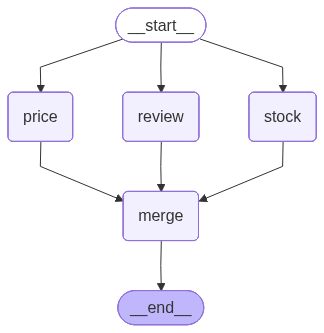

In [6]:
from IPython.display import Image, display;

display(Image(graph.get_graph().draw_mermaid_png()));

In [11]:
result = graph.invoke(
    {
        "product_name": "MacBook Pro",
        "price_result": "",
        "review_result": "",
        "stock_result": "",
        "final_summary": ""
    }
);

print("\n" + result["final_summary"])

[price]  Done → Price of MacBook Pro: $4,999

[stock]  Done → Stock of MacBook Pro: In Stock ✅ (42 units left)

[review] Done → Reviews of MacBook Pro: 4.3⭐ (1,240 reviews)

[merge] All branches complete. Building summary.

📦 Product Report for: MacBook Pro
  💰 Price of MacBook Pro: $4,999
  ⭐ Reviews of MacBook Pro: 4.3⭐ (1,240 reviews)
  📦 Stock of MacBook Pro: In Stock ✅ (42 units left)
